#  Matplotlib & Week 1 Mini-Notebook 

# Step 1:

### Import Required Libraries

The necessary Python libraries were imported for data analysis and visualization.

In [2]:
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 


### Load and Explore Dataset

The Titanic dataset was loaded using Pandas. The first rows were displayed, and missing values were checked to understand the dataset structure and prepare it for analysis.

In [3]:
df=pd.read_csv("Titanic-Dataset.csv")
df.head(5)
df.info
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

### Handling Missing Values

Missing values were handled by:
- Filling missing `Age` values with the mean age.
- Filling missing `Embarked` values with the most frequent value (mode).
- Removing the `Cabin` column because it contains many missing values.

In [41]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])
df=df.drop(columns=["Cabin"])

### Checking Missing Values After Cleaning

The dataset was checked again to confirm that the missing values were handled successfully after the data cleaning process.

In [42]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# Step 2: Creating a Derived Numeric Feature Using NumPy

NumPy was used to create the **FamilySize** feature by calculating the total number of family members traveling with each passenger.

Additionally, an **EconomicStatus** feature was created to categorize passengers based on their passenger class (`Pclass`).

In [ ]:
df["FamilySize"] = np.add(df["SibSp"], df["Parch"]) + 1
df["EconomicStatus"] = np.where(df["Pclass"] == 1, "High",
    np.where(df["Pclass"] == 2, "Medium", "Low"))

df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,EconomicStatus
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,Low
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,High
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,Low
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,High
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,Low


# Step 3: Data Visualization

### Age vs Fare

The scatter plot shows the relationship between passengers' ages and ticket fares. It helps explore whether there is any pattern between age and the amount paid for the ticket.

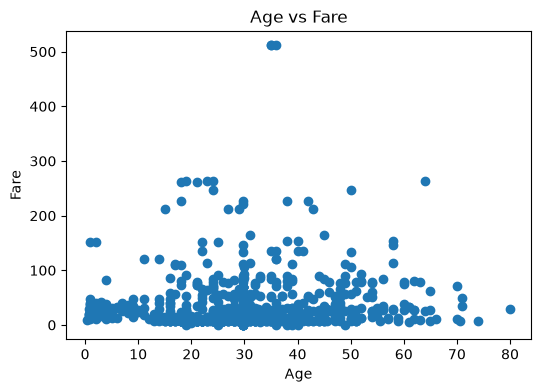

In [66]:
plt.figure(figsize=(6,4))

plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

### Interpretation

The scatter plot does not show a strong correlation between age and ticket fare. Passengers of different ages paid a wide range of fares, indicating that age was not the main factor affecting ticket prices. A few outliers with very high fares are also visible, while most passengers paid relatively low fares.

### Survival Rate

The pie chart shows the proportion of passengers who survived and those who did not. It gives an overview of the survival distribution in the dataset.

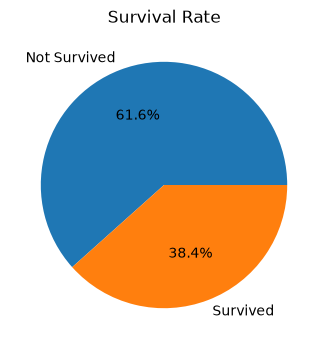

In [56]:
plt.figure(figsize=(6,4))

df["Survived"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Not Survived", "Survived"]
)

plt.title("Survival Rate")
plt.ylabel("")
plt.show()

### Interpretation

The pie chart shows that approximately **38.4%** of the passengers survived, while about **61.6%** did not survive. This indicates that the majority of passengers did not survive the disaster.

### Average Fare by Passenger Class

This bar chart compares the average ticket fare across different passenger classes. It shows that passengers in higher classes generally paid higher fares compared to lower classes.

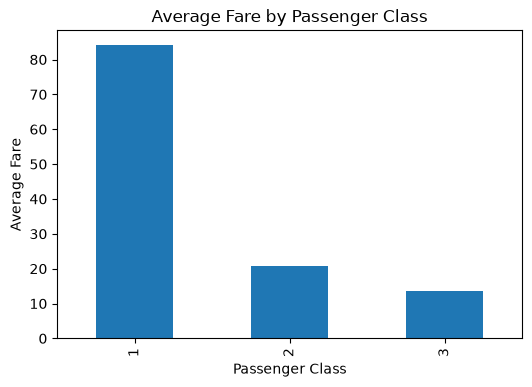

In [61]:
plt.figure(figsize=(6,4))

df.groupby("Pclass")["Fare"].mean().plot(kind="bar")

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.show()

### Interpretation

The bar chart shows that first-class passengers paid the highest average fare, followed by second-class passengers, while third-class passengers paid the lowest average fare. This indicates a clear difference in ticket prices between the passenger classes, with first-class tickets being significantly more expensive than the others.

### Age Distribution

This histogram shows the distribution of passengers' ages in the dataset. It helps identify the most common age groups, understand the spread of ages, and detect any potential outliers or skewness in the data.

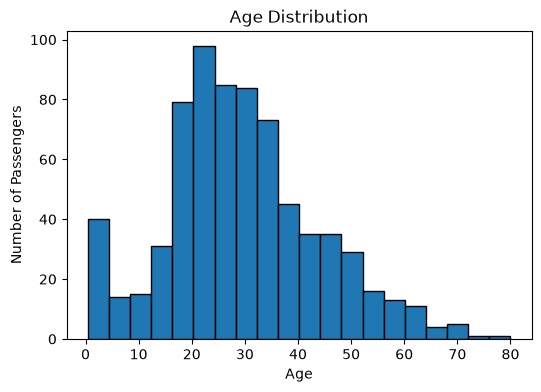

In [ ]:
plt.figure(figsize=(6,4))

plt.hist(df["Age"], bins=20
                ,edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Interpretation

The histogram shows that the majority of passengers were young adults, with ages mainly concentrated between 20 and 35 years. The number of passengers decreases gradually at older ages, while only a few passengers were over 60 years old. This suggests that the dataset contains a larger proportion of young adult passengers than elderly passengers.